In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score

In [5]:
x, y = make_classification(n_samples=5000, n_features=15, n_classes=2, weights=[0.6, 0.4], random_state=42)

col_names = [f"feature_{i}" for i in range(1, 16)]
print(x.shape, y.shape)

(5000, 15) (5000,)


In [6]:
df = pd.DataFrame(x, columns=col_names)
df['target'] = y

df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,target
0,0.280547,0.513707,0.600077,0.132933,-0.446743,-0.024305,1.925692,-1.975469,1.465833,0.266588,2.244387,-1.704060,-0.530315,-1.162787,0.862646,1
1,0.504257,0.491558,-0.180046,-0.169979,-0.595169,0.224075,-0.612825,-1.086411,-0.209787,-0.315192,-0.706853,-1.858125,0.694097,0.714817,-0.291406,0
2,-0.146550,0.550992,-0.342294,-0.078793,-0.023507,1.978164,-1.415985,0.931033,1.248097,-0.404016,-0.700930,-0.556282,-0.065374,-0.026593,1.255934,0
3,-0.941686,1.515026,0.252214,-0.882632,-0.732410,-1.784526,1.096197,0.145569,-1.266551,1.754573,0.173466,-0.121218,2.750949,-1.439122,-0.754718,1
4,0.160889,-0.417992,-0.425010,0.991153,0.157452,2.544566,-1.772444,-0.534075,1.643475,-1.200643,-1.727058,-1.147564,0.994472,1.124417,-0.448450,0


In [8]:
df.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,target
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.004138,0.007005,-0.060415,0.003887,0.022325,0.120615,-0.212979,0.004411,-0.022196,0.009810,0.008520,-0.029790,0.004383,-0.008007,0.002150,0.402400
std,1.017070,1.012700,0.388805,1.005272,0.989346,1.283823,1.360459,0.984037,1.215951,0.990072,1.010052,1.002439,1.009519,0.999844,0.999780,0.490431
min,-4.295391,-3.419906,-1.612523,-4.157734,-3.335902,-4.948272,-5.108021,-3.421380,-4.544072,-4.465604,-3.856375,-3.448043,-3.334893,-3.635200,-3.655087,0.000000
25%,-0.664974,-0.687355,-0.320802,-0.669996,-0.652633,-0.414536,-1.202595,-0.673941,-1.016052,-0.645214,-0.689193,-0.708190,-0.688733,-0.687107,-0.682445,0.000000
50%,-0.004197,0.007575,-0.080097,0.011435,0.027539,0.034628,-0.301556,0.026048,0.093780,0.019512,0.002979,-0.035853,0.000947,0.002753,0.010260,0.000000
75%,0.685718,0.703302,0.228536,0.692961,0.710235,0.580575,0.811186,0.669207,0.998655,0.682051,0.724974,0.648104,0.688797,0.659531,0.661239,1.000000
max,3.745379,3.727833,1.211331,3.691625,3.285724,4.835397,4.666389,3.451858,3.099966,4.479084,3.354573,3.611350,3.942331,3.471549,3.441520,1.000000


In [9]:
x = df.drop(columns="target")
y = df["target"]

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.20, random_state=42)

In [25]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)

model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [26]:
y_pred = model.predict(x_test)
y_proba = model.predict_proba(x_test)[:, 1]


print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.859
ROC-AUC: 0.929062879582023
[[514  84]
 [ 57 345]]


In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.86      0.88       598
           1       0.80      0.86      0.83       402

    accuracy                           0.86      1000
   macro avg       0.85      0.86      0.85      1000
weighted avg       0.86      0.86      0.86      1000



#### Compare overfitting

In [37]:
depths = list(range(1, 21))
results = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(x_train, y_train)
    
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    y_train_proba = model.predict_proba(x_train)[:, 1]
    y_test_proba = model.predict_proba(x_test)[:, 1]
    
    gap = train_accuracy - test_accuracy
    
    results.append({
        "max_depth": depth,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "train_test_accuracy_gap": gap,
        "train_auc": roc_auc_score(y_train, y_train_proba),
        "test_auc": roc_auc_score(y_test, y_test_proba),
        "train_test_auc_gap": accuracy_score(y_train, y_train_pred) - accuracy_score(y_test, y_test_pred)
    })

In [38]:
result_df = pd.DataFrame(results)

result_df

,max_depth,train_accuracy,test_accuracy,train_test_accuracy_gap,train_auc,test_auc,train_test_auc_gap
0,1,0.87125,0.861,0.01025,0.868340,0.858097,0.01025
1,2,0.87125,0.861,0.01025,0.917874,0.908478,0.01025
2,3,0.87875,0.859,0.01975,0.939805,0.929063,0.01975
3,4,0.90700,0.893,0.01400,0.965133,0.949252,0.01400
4,5,0.92400,0.901,0.02300,0.971728,0.952614,0.02300
5,6,0.93775,0.903,0.03475,0.978744,0.954995,0.03475
6,7,0.94950,0.895,0.05450,0.984987,0.934414,0.05450
7,8,0.96450,0.889,0.07550,0.989995,0.907394,0.07550
8,9,0.97350,0.891,0.08250,0.993793,0.899711,0.08250
9,10,0.98050,0.892,0.08850,0.996265,0.891323,0.08850


#### Plot train and test accuracy against max_depth

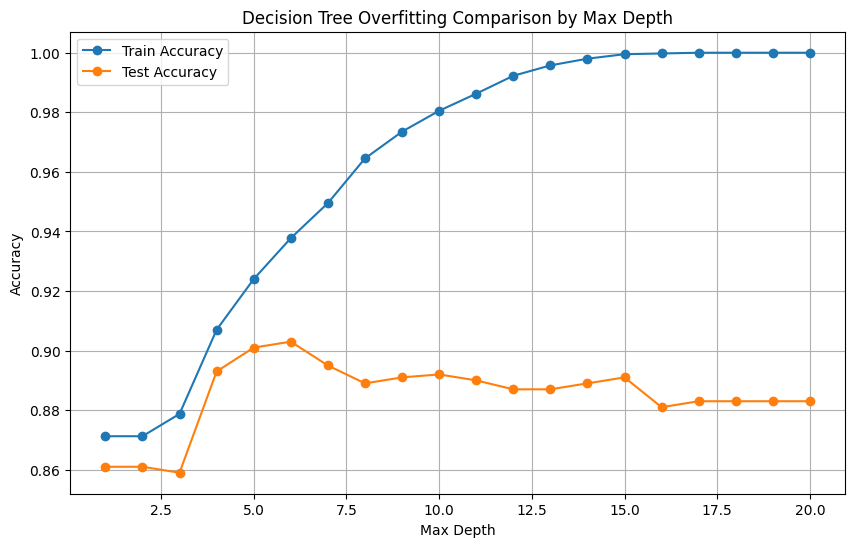

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(result_df["max_depth"], result_df["train_accuracy"], marker="o", label="Train Accuracy")
plt.plot(result_df["max_depth"], result_df["test_accuracy"], marker="o", label="Test Accuracy")

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Overfitting Comparison by Max Depth")
plt.legend()
plt.grid(True)
plt.show()

#### Compare accuracy and ROC-AUC for different max_depth values

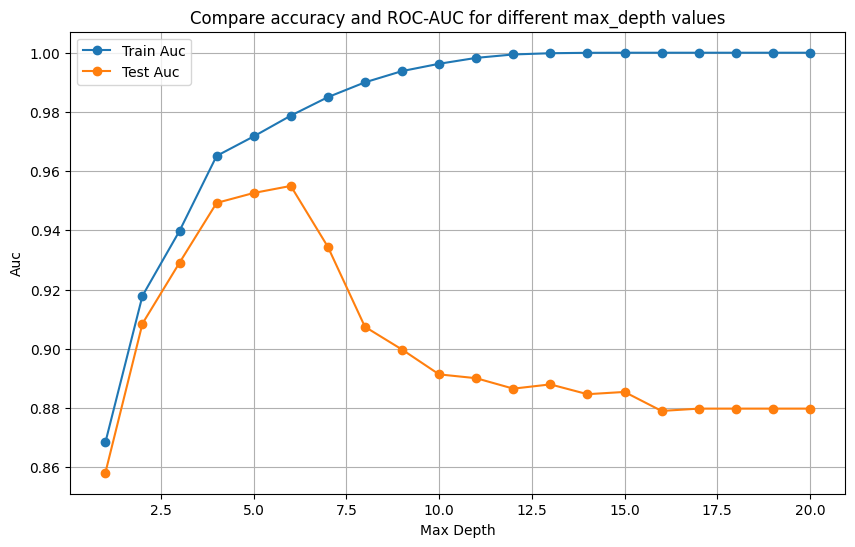

In [39]:
plt.figure(figsize=(10, 6))

plt.plot(result_df["max_depth"], result_df["train_auc"], marker="o", label="Train Auc")
plt.plot(result_df["max_depth"], result_df["test_auc"], marker="o", label="Test Auc")

plt.xlabel("Max Depth")
plt.ylabel("Auc")
plt.title("Compare accuracy and ROC-AUC for different max_depth values")
plt.legend()
plt.grid(True)
plt.show()

#### Optimal Depth

In [ ]:
best_row = result_df.loc[result_df["test_accuracy"].idxmax()]
best_row

max_depth                  6.000000
train_accuracy             0.937750
test_accuracy              0.903000
train_test_accuracy_gap    0.034750
train_auc                  0.978744
test_auc                   0.954995
train_test_auc_gap         0.034750
Name: 5, dtype: float64